In [4]:
## import the necessariy dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import SGD

###  1. Create a classification dataset using Scikit-Learn's make_moons() function, visualize it and then build a model to fit it at over 85% accuracy.

In [5]:
#import the dataset make moons
from sklearn.datasets import make_moons

# make 1000 samples
n_samples= 1000

# create moons
X, y = make_moons(n_samples,
                  random_state = 42,
                  noise = 0.02)

In [11]:
print(X)
print(y[:10]) # see first 10 labels

[[-0.00331218  0.38337854]
 [ 0.94351058 -0.48147221]
 [ 0.92575899 -0.44953496]
 ...
 [ 1.64957993 -0.28373727]
 [-0.92937318  0.36642651]
 [ 0.79815667  0.60246907]]
[1 1 1 1 0 1 1 1 1 0]


In [10]:
X.shape, y.shape

((1000, 2), (1000,))

In [12]:
# Make dataframe of features and labels

moons = pd.DataFrame({"X0":X[:, 0], "X1":X[:, 1], "label":y})
moons.head()

,X0,X1,label
0,-0.003312,0.383379,1
1,0.943511,-0.481472,1
2,0.925759,-0.449535,1
3,0.430470,-0.366058,1
4,-0.847017,0.527905,0


In [15]:
# lets chech the differences in shape
moons.label.value_counts()

,count
label,
1,500
0,500


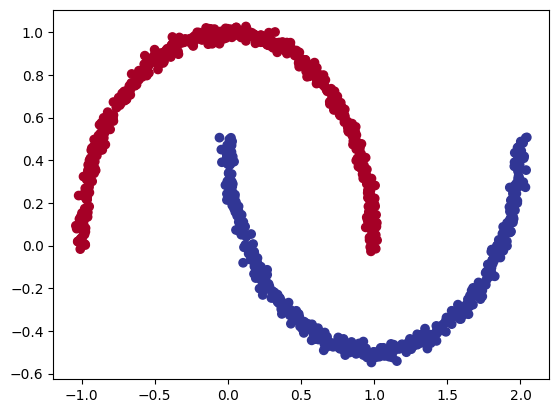

In [19]:
# visualise with a plot
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)


In [20]:
# Build a simple model

#set a random seed
tf.random.set_seed(42)

# build a sequential model
model_1 = Sequential([
    Dense(1)
])

# complie the model
model_1.compile(
    loss = BinaryCrossentropy(),
    optimizer = SGD(),
    metrics = ["accuracy"]
)

# fit the model
model_1.fit(X,y, epochs= 5)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6444 - loss: 2.5101
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8815 - loss: 0.3309 
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8958 - loss: 0.2236 
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8952 - loss: 0.2220 
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8953 - loss: 0.2215 


In [26]:
# let's evaluate the model
model_1.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8854 - loss: 0.2310


[0.2245311141014099, 0.8939999938011169]

In [28]:
# imporve mode_1 by adding another hidden layer and increase the training epoch

#set a random seed
tf.random.set_seed(42)

# build a sequential model
model_2 = Sequential([
    Dense(1),
    Dense(1)
])

# complie the model
model_2.compile(
    loss = BinaryCrossentropy(),
    optimizer = SGD(),
    metrics = ["accuracy"]
)

# fit the model
model_2.fit(X,y, epochs= 100, verbose = 0)

In [29]:
model_2.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8781 - loss: 0.2299


[0.22240635752677917, 0.8880000114440918]

In [32]:
loss, accuracy = model_2.evaluate(X,y)
print("accuracy: ", accuracy)
print("loss: ", loss )

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8781 - loss: 0.2299 
accuracy:  0.8880000114440918
loss:  0.22240635752677917
